In [2]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
from numpy.fft import fftn, ifftn, fftfreq
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import binned_statistic
import concurrent.futures
from scipy.stats import linregress

In [3]:
galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[30])

Slicing:   2%|▏         | 8/500 [00:00<00:34, 14.10it/s]

Slicing: 100%|██████████| 500/500 [00:33<00:00, 15.02it/s]


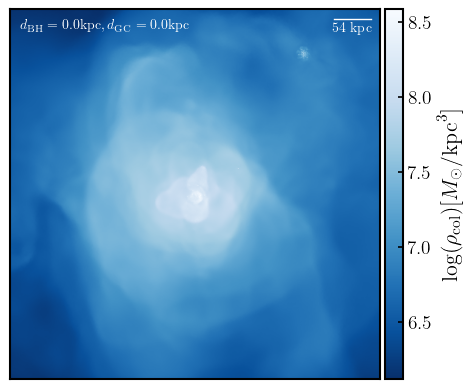

In [6]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)

fig, ax = plt.subplots()
structured_gas = nicegalaxy.structured_column(galaxy.gas["Coordinates"], galaxy.gas["Density"]*galaxy.gas["InternalEnergy"], grid_size=500)
scalebar_length = round(box_length/10)
scalebar_pixels = scalebar_length/box_length * structured_gas.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
im = ax.imshow(np.log10(structured_gas) + 10, cmap="Blues_r", interpolation=None)
ax.plot([structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels, structured_gas.shape[0]*(1 - 1/40)], [structured_gas.shape[0]/40, structured_gas.shape[0]/40], color='white', linewidth=1)
ax.text(structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_gas.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
ax.text(structured_gas.shape[0]*1/40, structured_gas.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\mathrm{log}(\rho_{\mathrm{col}}) [M_{\odot}/\mathrm{kpc}^3]$")
# fig.savefig("radial/galaxy.png")

In [9]:
distances = np.linalg.norm(galaxy.gas["Coordinates"]- galaxy.bhs["Coordinates"][0], axis=-1)
bin_edges = np.logspace(np.log10(distances.min()), np.log10(distances.max()), 500)
vols = galaxy.gas["Masses"]/galaxy.gas["Density"]
hist1, _, _ = binned_statistic(distances, galaxy.gas["Density"] * vols, bins=bin_edges, statistic='sum')
hist2, _, _ = binned_statistic(distances, vols, bins=bin_edges, statistic='sum')
hist = np.where((~np.isnan(hist2)) & (~np.isnan(hist1)) & (hist2 != 0), hist1 / hist2, 0.0)
hist3, _, _ = binned_statistic(distances, galaxy.gas["Density"], bins=bin_edges, statistic='median')
dist_bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

/tmp/ipykernel_50651/3642478197.py:6: RuntimeWarning: invalid value encountered in divide
  hist = np.where((~np.isnan(hist2)) & (~np.isnan(hist1)) & (hist2 != 0), hist1 / hist2, 0.0)


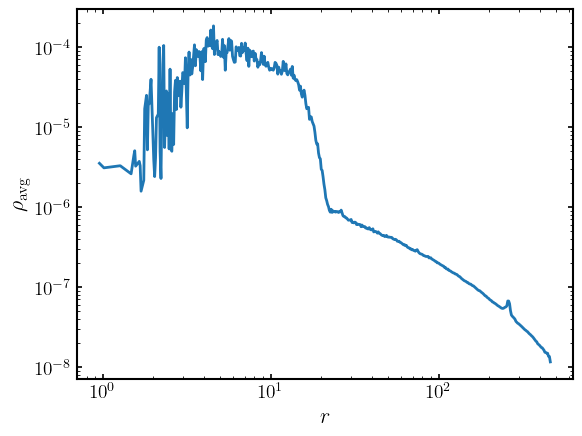

In [10]:
fig, ax = plt.subplots()
ax.plot(dist_bin_centers[~np.isnan(hist)& (hist != 0)], hist[~np.isnan(hist)& (hist != 0)])
# ax.plot(dist_bin_centers, hist3)
ax.set_yscale("log")
ax.set_xscale("log")
# for coord in galaxy.bhs["Coordinates"]:
#     ax.axvline(x=np.linalg.norm(coord - galaxy.bhs["Coordinates"][0]), linestyle="--", color="red")

x = np.log10(dist_bin_centers[hist > 0])
y = np.log10(hist[hist > 0])
slope, intercept, r_value, p_value, std_err = linregress(x, y)
y_fit = 10**(intercept) * dist_bin_centers**(slope)
# ax.plot(dist_bin_centers, y_fit)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\rho_{\mathrm{avg}}$")
fig.savefig("radial/radialprofile.pdf")

In [56]:
zero_indices = np.where(hist == 0)[0]
nonzero_indices = np.where(hist != 0)[0]

# Loop through each zero-value and replace it
for i in zero_indices:
    # Find the index j of the non-zero y that is closest in x
    closest_j = nonzero_indices[np.argmin(np.abs(dist_bin_centers[nonzero_indices] - x[i]))]
    hist[i] = hist[closest_j]

In [57]:
hist[hist == 0]

array([], dtype=float64)

In [55]:
dens_copy = 10**(intercept) * np.linalg.norm(galaxy.gas["Coordinates"] - galaxy.bhs["Coordinates"][0], axis=-1)**(slope)

In [11]:
distances = np.linalg.norm(galaxy.gas["Coordinates"]- galaxy.bhs["Coordinates"][0], axis=-1)
idx = np.abs(distances[:, None] - dist_bin_centers[~np.isnan(hist)& (hist != 0)][None, :]).argmin(axis=1)
dens_copy = hist[idx]
print(dens_copy.shape)

(1736021,)


/tmp/ipykernel_52842/2984490755.py:7: RuntimeWarning: divide by zero encountered in divide
  structured_gas = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.log(galaxy.gas["Density"]/dens_copy), grid_size=500)
Slicing: 100%|██████████| 500/500 [00:30<00:00, 16.24it/s]


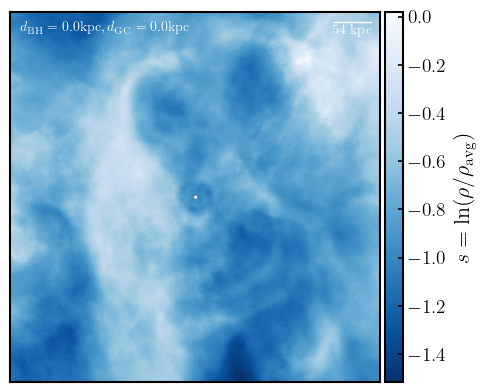

In [14]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)

fig, ax = plt.subplots()
structured_gas = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.log(galaxy.gas["Density"]/dens_copy), grid_size=500)
scalebar_length = round(box_length/10)
scalebar_pixels = scalebar_length/box_length * structured_gas.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
im = ax.imshow(structured_gas, cmap="Blues_r", interpolation=None)
ax.plot([structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels, structured_gas.shape[0]*(1 - 1/40)], [structured_gas.shape[0]/40, structured_gas.shape[0]/40], color='white', linewidth=1)
ax.text(structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_gas.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
ax.text(structured_gas.shape[0]*1/40, structured_gas.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$s = \ln(\rho/\rho_{\mathrm{avg}})$")# label=r"$\mathrm{log}(\rho) [M_{\odot}/\mathrm{kpc}^3]$")
fig.savefig("radial/density_contrast.png")

In [39]:
def mean(vals, weights):
    if len(vals.shape) == 1:
        return np.sum(vals*weights)/np.sum(weights)
    else:
        return np.sum(vals*weights[:, None], axis=0)/np.sum(weights)


def variance(vals, weights):
    return np.sqrt(mean(vals**2, weights) - mean(vals, weights)**2)


def galaxy_cutouts(boxes, smoothing, masses, density, dens_copy):
    box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

    min_corner = galaxy.gas["Coordinates"].min(axis=0)
    max_corner = galaxy.gas["Coordinates"].max(axis=0)
    cutout_size = box_length/2**smoothing

    spacing = (max_corner - min_corner - cutout_size) / (boxes - 1)
    results = np.zeros((boxes**3, 10))
    # for i, j, k in tqdm(np.ndindex(boxes, boxes, boxes), total=boxes**3, desc="Processing cutouts"):
    tasks = [(i, j, k) for i in range(boxes) for j in range(boxes) for k in range(boxes)]
    def cutout_calculation(i, j, k):
        cutout_min = min_corner + np.array([i, j, k]) * spacing
        cutout_max = cutout_min + cutout_size
        in_box = (
            (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
            (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
            (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
        )
        center = 0.5 * (cutout_max + cutout_min)
        closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
        gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
        vols = masses[in_box]/density[in_box]

        # density stuff
        dens_mean_v = mean(density[in_box], vols)
        dens_mean_m = mean(density[in_box], masses[in_box])

        s_v = np.log(density[in_box]/dens_mean_v) # log not log10
        s_m = np.log(density[in_box]/dens_mean_m)

        s_corrected = np.log(density[in_box]/dens_copy[in_box])

        results[i * boxes**2 + j * boxes + k, 0] = gc_dist
        results[i * boxes**2 + j * boxes + k, 1] = closest_bh_dist
        results[i * boxes**2 + j * boxes + k, 2] = dens_mean_v
        results[i * boxes**2 + j * boxes + k, 3] = dens_mean_m
        results[i * boxes**2 + j * boxes + k, 4] = variance(density[in_box], vols)
        results[i * boxes**2 + j * boxes + k, 5] = variance(density[in_box], masses[in_box])
        results[i * boxes**2 + j * boxes + k, 6] = variance(s_v, vols)
        results[i * boxes**2 + j * boxes + k, 7] = variance(s_m, masses[in_box])
        results[i * boxes**2 + j * boxes + k, 8] = variance(s_corrected, vols)
        results[i * boxes**2 + j * boxes + k, 9] = variance(s_corrected, masses[in_box])

    thread_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(cutout_calculation, i, j, k) for i, j, k in tasks]
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            thread_results.append(future.result())
    return results


def galaxy_cutouts_dens_pdf(axs, boxes, smoothing, masses, density, dens_copy, tasks=([4, 4, 4])):
    box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

    min_corner = galaxy.gas["Coordinates"].min(axis=0)
    max_corner = galaxy.gas["Coordinates"].max(axis=0)
    cutout_size = box_length/2**smoothing

    spacing = (max_corner - min_corner - cutout_size) / (boxes - 1)
    # for i, j, k in tqdm(np.ndindex(boxes, boxes, boxes), total=boxes**3, desc="Processing cutouts"):
    # tasks = [(4, 4, 4)] # [(i, j, k) for i in range(boxes) for j in range(boxes) for k in range(boxes)]
    def cutout_calculation(i, j, k):
        cutout_min = min_corner + np.array([i, j, k]) * spacing
        cutout_max = cutout_min + cutout_size
        in_box = (
            (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
            (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
            (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
        )
        center = 0.5 * (cutout_max + cutout_min)
        closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
        gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
        vols = masses[in_box]/density[in_box]

        # density stuff
        dens_mean_v = mean(density[in_box], vols)
        dens_mean_m = mean(density[in_box], masses[in_box])
        print(dens_mean_m, dens_mean_v)

        s_v = np.log(density[in_box]/dens_mean_v) # log not log10
        s_m = np.log(density[in_box]/dens_mean_m)

        dens_copy_mean_v = mean(dens_copy[in_box], vols)
        s_copy = np.log(dens_copy[in_box]/dens_copy_mean_v)


        s_corrected = np.log(density[in_box]/dens_copy[in_box])
        axs[0, 0].hist(s_corrected, bins=50, density=True, histtype='step', alpha=0.3, color='blue')
        axs[0, 1].hist(s_v, bins=50, density=True, histtype='step', alpha=0.3, color='blue')
        axs[1, 0].hist(dens_copy[in_box], bins=50, density=True, histtype='step', alpha=0.3, color='blue')
        axs[1, 1].hist(s_m, bins=50, density=True, histtype='step', alpha=0.3, color='blue')

    thread_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(cutout_calculation, i, j, k) for i, j, k in tasks]
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            thread_results.append(future.result())

In [86]:
big_boxes = galaxy_cutouts(20, 3, galaxy.gas["Masses"], dens_copy)
small_boxes = galaxy_cutouts(20, 4, galaxy.gas["Masses"], dens_copy)

100%|██████████| 8000/8000 [00:25<00:00, 319.94it/s]


In [ ]:
big_boxes_regular = galaxy_cutouts(20, 3, galaxy.gas["Masses"], galaxy.gas["Density"])
small_boxes_regular = galaxy_cutouts(20, 4, galaxy.gas["Masses"], galaxy.gas["Density"])

100%|██████████| 8000/8000 [00:30<00:00, 259.70it/s]


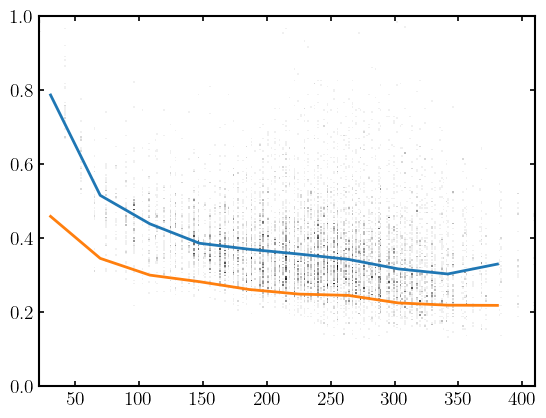

In [99]:
fig, ax = plt.subplots()

X = big_boxes_regular[:, 0]
Y = big_boxes_regular[:, 6]
ax.hist2d(X, Y, cmap="Grays", bins=300)
ax.set_ylim(0, 1)

total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins - delta/2, running_median)

X = small_boxes_regular[:, 0]
Y = small_boxes_regular[:, 6]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins - delta/2, running_median)
fig.show()

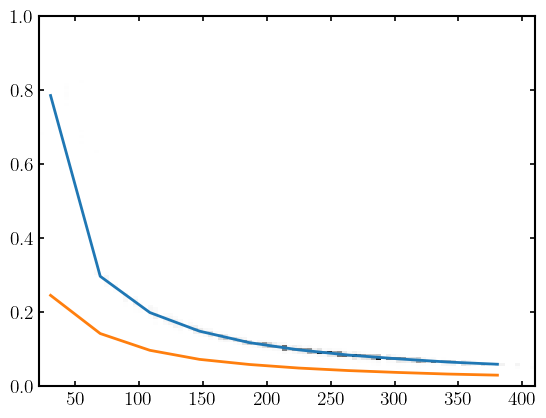

In [ ]:
fig, ax = plt.subplots()

X = big_boxes[:, 0]
Y = big_boxes[:, 6]
ax.hist2d(X, Y, cmap="Grays", bins=100)
ax.set_ylim(0, 1)

total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins - delta/2, running_median)

X = small_boxes[:, 0]
Y = small_boxes[:, 6]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins - delta/2, running_median)
fig.show()

In [8]:
big_boxes_corrected = galaxy_cutouts(20, 3, galaxy.gas["Masses"], galaxy.gas["Masses"], dens_copy)
small_boxes_corrected = galaxy_cutouts(20, 4, galaxy.gas["Masses"], galaxy.gas["Masses"], dens_copy)

100%|██████████| 8000/8000 [00:26<00:00, 300.68it/s]


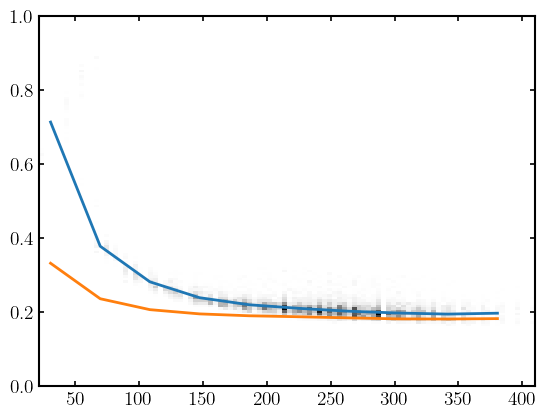

In [13]:
fig, ax = plt.subplots()

X = big_boxes_corrected[:, 0]
Y = big_boxes_corrected[:, 8]
ax.hist2d(X, Y, cmap="Grays", bins=100)
ax.set_ylim(0, 1)

total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins - delta/2, running_median)

X = small_boxes_corrected[:, 0]
Y = small_boxes_corrected[:, 8]
idx  = np.digitize(X,bins)
running_median = [np.median(Y[idx==k]) for k in range(total_bins)]
ax.plot(bins - delta/2, running_median)
fig.show()

Slicing: 100%|██████████| 500/500 [00:30<00:00, 16.16it/s]


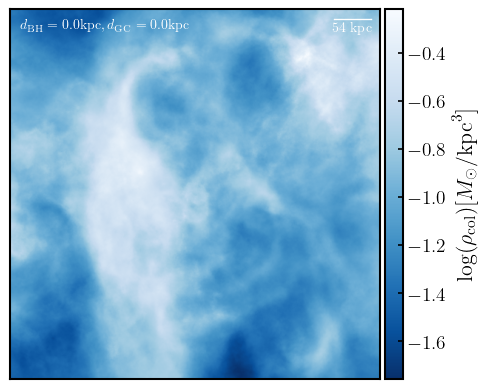

In [22]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)

fig, ax = plt.subplots()
structured_gas = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.log(galaxy.gas["Density"]/dens_copy), grid_size=500)
scalebar_length = round(box_length/10)
scalebar_pixels = scalebar_length/box_length * structured_gas.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
im = ax.imshow(structured_gas, cmap="Blues_r", interpolation=None)
ax.plot([structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels, structured_gas.shape[0]*(1 - 1/40)], [structured_gas.shape[0]/40, structured_gas.shape[0]/40], color='white', linewidth=1)
ax.text(structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_gas.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
ax.text(structured_gas.shape[0]*1/40, structured_gas.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\mathrm{log}(\rho_{\mathrm{col}}) [M_{\odot}/\mathrm{kpc}^3]$")
fig.show()

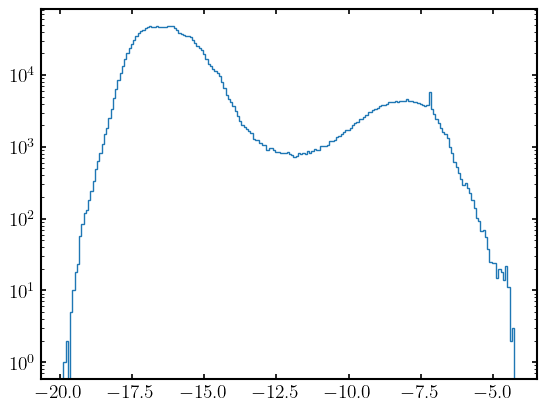

In [18]:
fig, ax = plt.subplots()

ax.hist(np.log(galaxy.gas["Density"]), bins=200, histtype="step")
ax.set_yscale("log")
fig.show()

100%|██████████| 1/1 [00:00<00:00, 22.09it/s]


1.0954466e-07 9.471532e-08


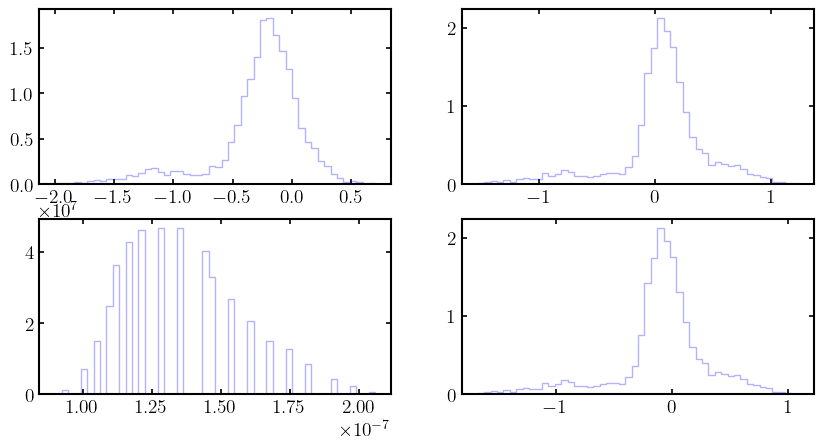

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

galaxy_cutouts_dens_pdf(axs, 20, 3, galaxy.gas["Masses"], galaxy.gas["Density"], dens_copy, tasks=[(5, 5, 5)])

In [27]:
dens_copy[dens_copy == 0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [29]:
np.mean(np.log(np.where(dens_copy != 0, galaxy.gas["Density"]/dens_copy, 1)))

/tmp/ipykernel_52842/3286845035.py:1: RuntimeWarning: divide by zero encountered in divide
  np.mean(np.log(np.where(dens_copy != 0, galaxy.gas["Density"]/dens_copy, 1)))


np.float64(-0.16414354730974293)

/tmp/ipykernel_52842/3013044774.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.hist(np.log(np.where(dens_copy != 0, galaxy.gas["Density"]/dens_copy, 1)), bins=200)


(-2.5, 2.5)

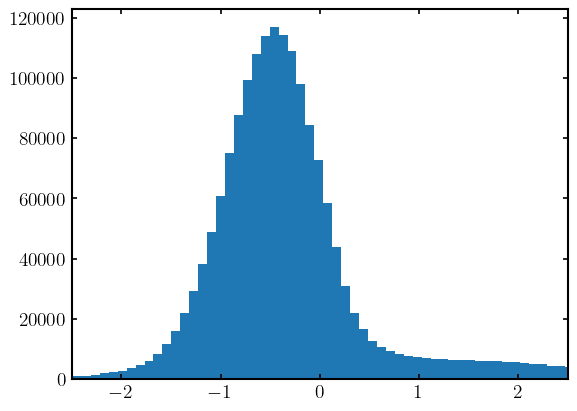

In [31]:
plt.hist(np.log(np.where(dens_copy != 0, galaxy.gas["Density"]/dens_copy, 1)), bins=200)
plt.xlim(-2.5, 2.5)